In [10]:
import networkx as nx
import random
import math

# Create NSFNET-4 graph
G = nx.Graph()
G.add_edge(1, 2, weight=2800)  # km
G.add_edge(2, 3, weight=1200)
G.add_edge(2, 4, weight=1200)
G.add_edge(3, 4, weight=1400)

nodes = [1, 2, 3, 4]

classify partitions and assign probabilities that a lightpath request will require certain bandwidth slots

In [11]:
demand_types = [
    {'b_l':2, 'prob':0.35},
    {'b_l':3, 'prob':0.20},
    {'b_l':4, 'prob':0.15},
    {'b_l':5, 'prob':0.12},
    {'b_l':6, 'prob':0.10},
    {'b_l':7, 'prob':0.08},
]

Generate 1000 lightpath requests

In [12]:
requests = []                      # Empty list — we will fill it with requests
for i in range(1000):                # Loop 1000 times → create 1000 requests
    s = random.choice(nodes)       # Pick random source node (from [1,2,3,4])
    d = random.choice(nodes)       # Pick random destination node
    while s == d:                  # Keep picking d until it's different from s
        d = random.choice(nodes)
    
    path = nx.shortest_path(G, s, d)   # Find the shortest path (list of nodes, e.g. [1,2,4])
    
    # Pick demand type
    r = random.random()            # returns a floating point number between 0.0 and 1.0
    cum = 0.0                      # Cumulative probability starts at 0
    chosen_dt = None               # Will store the chosen demand type
    for dt in demand_types:        # Loop through your demand_types list
        cum += dt['prob']          # Add this type's probability to cumulative
        if r < cum:                # If random r falls in this range → choose this type
            chosen_dt = dt
            break                  # Stop looping — we found it
    
    requests.append({              # Add this request as a dictionary
        'id': i+1,                 # Request number (1 to 20)
        'source': s,
        'dest': d,
        'path': path,              # List of nodes on the path
        'b_l': chosen_dt['b_l'],   # Number of slots needed (from chosen type)
    })

In [13]:
print(requests)

[{'id': 1, 'source': 3, 'dest': 2, 'path': [3, 2], 'b_l': 3}, {'id': 2, 'source': 2, 'dest': 4, 'path': [2, 4], 'b_l': 2}, {'id': 3, 'source': 1, 'dest': 4, 'path': [1, 2, 4], 'b_l': 2}, {'id': 4, 'source': 3, 'dest': 4, 'path': [3, 4], 'b_l': 6}, {'id': 5, 'source': 3, 'dest': 2, 'path': [3, 2], 'b_l': 3}, {'id': 6, 'source': 2, 'dest': 1, 'path': [2, 1], 'b_l': 2}, {'id': 7, 'source': 1, 'dest': 4, 'path': [1, 2, 4], 'b_l': 2}, {'id': 8, 'source': 1, 'dest': 4, 'path': [1, 2, 4], 'b_l': 6}, {'id': 9, 'source': 3, 'dest': 2, 'path': [3, 2], 'b_l': 4}, {'id': 10, 'source': 3, 'dest': 2, 'path': [3, 2], 'b_l': 7}, {'id': 11, 'source': 4, 'dest': 1, 'path': [4, 2, 1], 'b_l': 3}, {'id': 12, 'source': 3, 'dest': 2, 'path': [3, 2], 'b_l': 3}, {'id': 13, 'source': 1, 'dest': 4, 'path': [1, 2, 4], 'b_l': 3}, {'id': 14, 'source': 1, 'dest': 2, 'path': [1, 2], 'b_l': 5}, {'id': 15, 'source': 4, 'dest': 1, 'path': [4, 2, 1], 'b_l': 3}, {'id': 16, 'source': 4, 'dest': 2, 'path': [4, 2], 'b_l': 3}

initialize spectrum map for all links

In [ ]:
# Initialize spectrum map for all links
F = 720  # your size
all_links = [frozenset(edge) for edge in G.edges()]
spectrum_map = {link: [0] * F for link in all_links}

In [15]:


# Repeating pattern of block sizes
pattern = [2, 3, 4, 5, 6, 7]  # sizes

# Create a map: slot → dedicated b_l (0 = not partitioned, but we cover all)
slot_dedicated_b_l = [0] * F

current_slot = 0
while current_slot < F:
    for block_size in pattern:
        if current_slot + block_size > F:
            break  # leftover slots at end
        for i in range(block_size):
            slot_dedicated_b_l[current_slot + i] = block_size
        current_slot += block_size

print("First 100 slots:", slot_dedicated_b_l[:100])
# Output: [2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 2, 2, 3] ...

First 100 slots: [2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6]


In [16]:
def try_allocate(request):
    b_l = request['b_l']
    path = request['path']
    
    for start in range(1, F - b_l + 2):
        if slot_dedicated_b_l[start-1] != b_l:
            continue

        can_allocate = True
        for i in range(len(path) - 1):
            link = frozenset({path[i], path[i+1]})
            
            # Check 1 guard slot BEFORE the block
            if start - 2 >= 0:  # slot before exists
                if spectrum_map[link][start - 2] != 0:
                    can_allocate = False
                    break
            
            # Check the block itself
            for offset in range(b_l):
                slot_idx = start + offset - 1
                if spectrum_map[link][slot_idx] != 0:
                    can_allocate = False
                    break
            
            # Check 1 guard slot AFTER the block
            if can_allocate:
                end_idx = start + b_l - 1  # slot index after block
                if end_idx < F:
                    if spectrum_map[link][end_idx] != 0:
                        can_allocate = False
                        break
            
            if not can_allocate:
                break
        
        if can_allocate:
            for i in range(len(path) - 1):
                link = frozenset({path[i], path[i+1]})
                for offset in range(b_l):
                    slot_idx = start + offset - 1
                    spectrum_map[link][slot_idx] = b_l
            
            request['allocated'] = True
            request['start_slot'] = start
            return True
    
    request['allocated'] = False
    return False

In [17]:
# Allocate all requests
allocated_count = 0
for req in requests:
    if try_allocate(req):
        allocated_count += 1

print(f"Allocated {allocated_count} out of {len(requests)} requests")
print(f"Blocking rate: {1 - allocated_count/len(requests):.2%}")

Allocated 380 out of 1000 requests
Blocking rate: 62.00%


/tmp/ipykernel_8544/1703991682.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


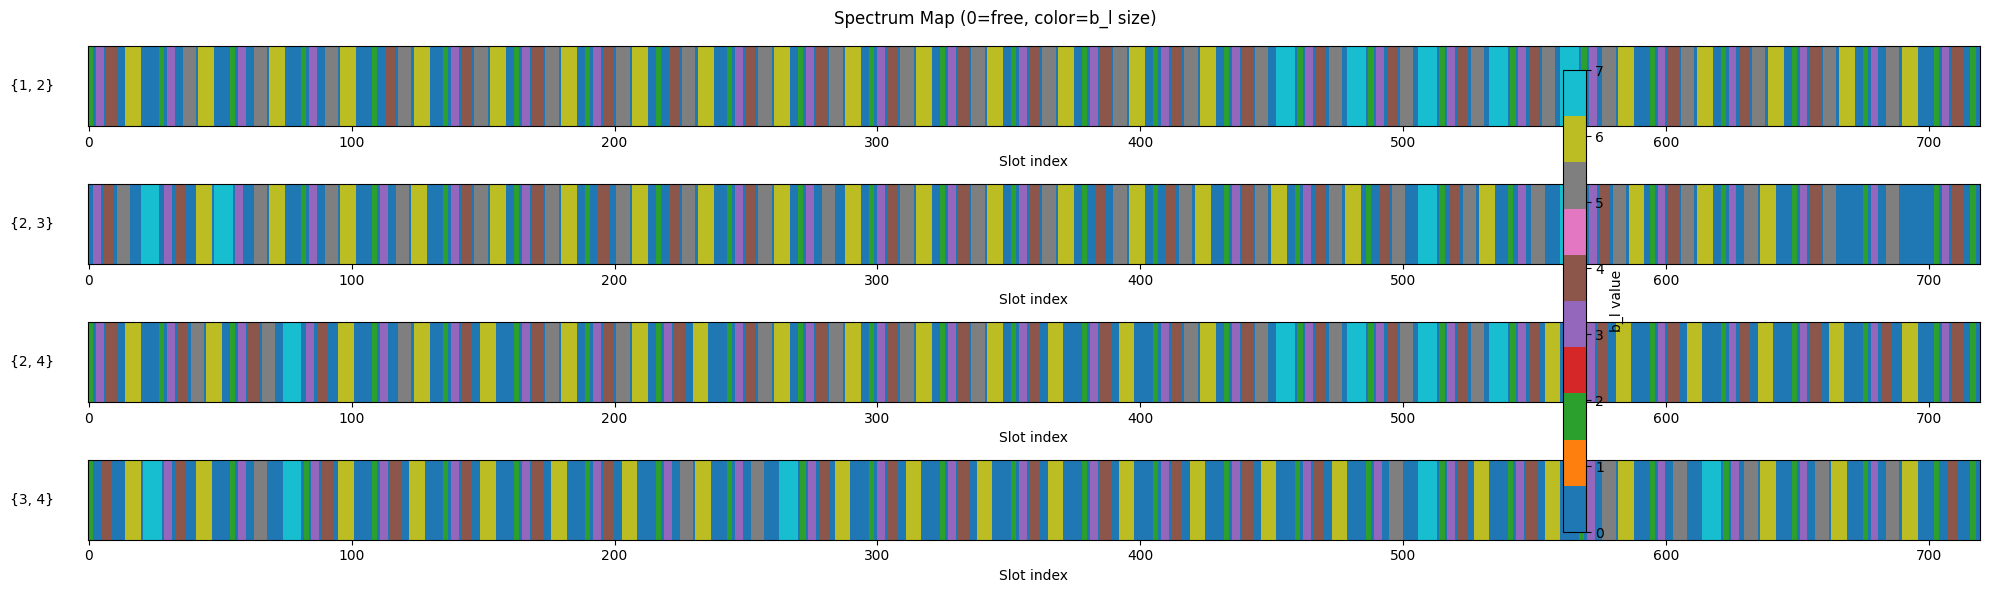

In [18]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(len(all_links), 1, figsize=(20, 6))

for ax, link in zip(axes, all_links):
    data = np.array(spectrum_map[link]).reshape(1, -1)
    
    im = ax.imshow(
        data,
        aspect='auto',
        cmap='tab10',
        vmin=0,
        vmax=7,
        interpolation='none'
    )
    
    ax.set_ylabel(str(set(link)), rotation=0, labelpad=40, va='center')
    ax.set_yticks([])
    ax.set_xlabel("Slot index")

# Now im exists (last one created)
cbar = fig.colorbar(im, ax=axes, ticks=[0,1,2,3,4,5,6,7])
cbar.set_label('b_l value')

plt.suptitle("Spectrum Map (0=free, color=b_l size)")
plt.tight_layout()
plt.show()

In [ ]:
for link in all_links:
    free = spectrum_map[link].count(0)
    print(f"Link {set(link)}: {free}/720 slots free ({free/720:.1%})")

Link {1, 2}: 270/720 slots free (37.5%)
Link {2, 3}: 287/720 slots free (39.9%)
Link {2, 4}: 238/720 slots free (33.1%)
Link {3, 4}: 311/720 slots free (43.2%)
